# Assessment 2 — Machine Learning for Time Series Forecasting

## 1. Previous Descriptive Analysis and Results

In Assessment 1, a comprehensive exploratory data analysis of daily net retail sales from May 2000 to April 2003 was conducted, revealing significant **weekly** and **yearly** seasonality alongside high-amplitude volatility. A SARIMAX model was implemented to establish a statistical baseline for forecasting. While the model successfully captured the general sales level and the rhythmic weekly patterns, it struggled to accurately predict the magnitude of extreme sales spikes, resulting in a **MAPE of 49.13 %**, and **MAE of 121,217**, and an **RMSE of 149,494**. Residual diagnostics indicated that the linear model had not fully extracted all available signals, with errors concentrated around extreme events. These results highlight the limitations of purely statistical linear models when confronted with non-linear, event-driven data, providing a clear rationale for transitioning to the machine learning approaches explored in this assessment.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Data Preprocessing

### 2.1 Data Loading & Cleaning

We reproduce the exact preprocessing pipeline from Assessment 1 in a single consolidated cell:
1. Load the CSV and set a `DatetimeIndex` with daily frequency
2. Trim the initial missing-data block (before 2000-07-10). This segment contained a large contiguous gap with no reliable data to anchor interpolation, and retaining it would introduce systematic bias.
3. Impute the remaining isolated gaps with **linear interpolation**. The surviving gaps are short and the series shows no abrupt structural breaks at those points, so a smooth local estimate between neighbours is appropriate.


Missing before imputation: 86
Series range : 2000-07-10  →  2003-04-06
Total days   : 1001
Missing after imputation: 0


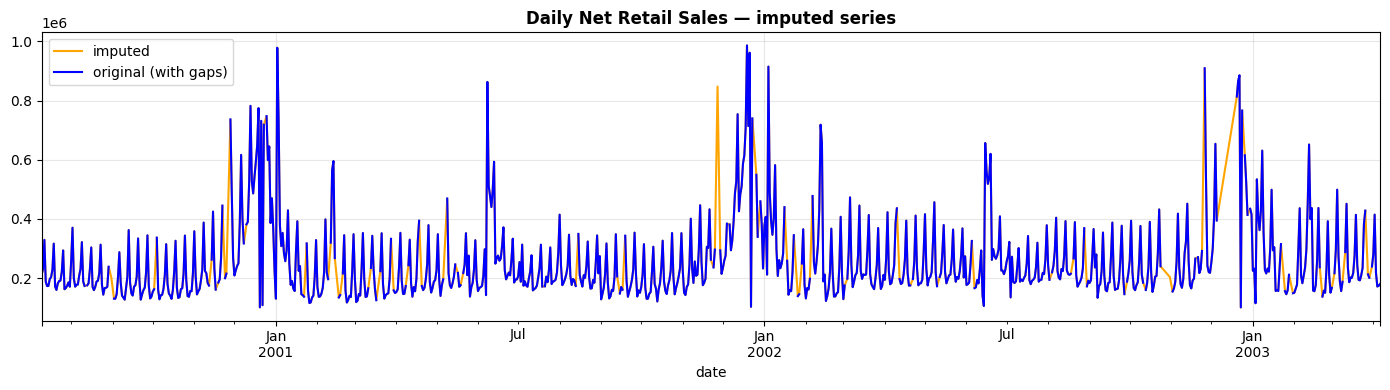

In [2]:
# ── Load & basic cleaning ────────────────────────────────────────────────────
data_raw = pd.read_csv('07_Daily net retail sales. 5 May 2000 – 6 April 2003..csv')
data_raw['date'] = pd.to_datetime(data_raw['date'], format='%Y-%m-%d')
data_raw = data_raw.set_index('date').asfreq('D').sort_index()

# ── Trim the large initial missing block (as decided in Assessment 1) ─────────
data_trimmed = data_raw.loc['2000-07-10':].copy()

# ── Impute remaining gaps with linear interpolation ───────────────────────────
data_imputed = data_trimmed.copy()
print(f"Missing before imputation: {data_imputed['sales'].isna().sum()}")
data_imputed['sales'] = data_imputed['sales'].interpolate(method='linear')

print(f"Series range : {data_imputed.index.min().date()}  →  {data_imputed.index.max().date()}")
print(f"Total days   : {len(data_imputed)}")
print(f"Missing after imputation: {data_imputed['sales'].isna().sum()}")

# ── Quick visual confirmation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
data_imputed['sales'].plot(ax=ax, color='orange', label='imputed')
data_trimmed['sales'].plot(ax=ax, color='blue', label='original (with gaps)')
ax.set_title('Daily Net Retail Sales — imputed series', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

After imputation, **zero missing values** remain across the full series. The overlay plot confirms that the imputed values blend naturally into the surrounding data without introducing visible artefacts.

### 2.2 Feature Engineering

For machine learning models, the time series must be converted into a supervised-learning table where each row represents one day and the columns are predictive features.
The features created are:

| Group | Features | Rationale |
|---|---|---|
| **Calendar** | day-of-week, month, quarter, is_weekend, is_holiday, is_summer | Encode both weekly and yearly seasonality without requiring explicit seasonal differencing |


In [3]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add calendar and holiday features to the sales dataframe."""
    df = df.copy()

    # 1. Calendar features
    df['day_of_week'] = df.index.dayofweek
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['is_weekend']  = df.index.dayofweek.isin([5, 6]).astype(int)

    # 2. Holiday/Summer Features (US Context)
    us_holidays = holidays.US()
    # Binary feature: 1 if date is a holiday
    df['is_holiday'] = df.index.map(lambda x: 1 if x in us_holidays else 0)
    
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)

    return df

df_ml = create_features(data_imputed).dropna()

print(f"Shape after feature engineering: {df_ml.shape}")
display(df_ml.head())

Shape after feature engineering: (1001, 7)


,sales,day_of_week,month,quarter,is_weekend,is_holiday,is_summer
date,,,,,,,
2000-07-10,213038.0,0,7,3,0,0,1
2000-07-11,231461.0,1,7,3,0,0,1
2000-07-12,329375.0,2,7,3,0,0,1
2000-07-13,188393.0,3,7,3,0,0,1
2000-07-14,173321.0,4,7,3,0,0,1


### 2.3 Train / Test Split

The dataset is split chronologically: the **final 200 days** are reserved as a hold-out test set (~20% of the data), remaining completely untouched until the final evaluation step. The remaining **801 days** form the training set. Splitting by time, rather than randomly, is essential for time series data, as random splitting would leak future information into the training set and produce overly optimistic performance estimates.

Model selection and hyperparameter tuning are performed exclusively on the training portion using **Time Series Cross-Validation (expanding window)**, as described in the next sections.

Train: 2000-07-10 → 2002-09-18  (n=801)
Test : 2002-09-19  → 2003-04-06   (n=200)


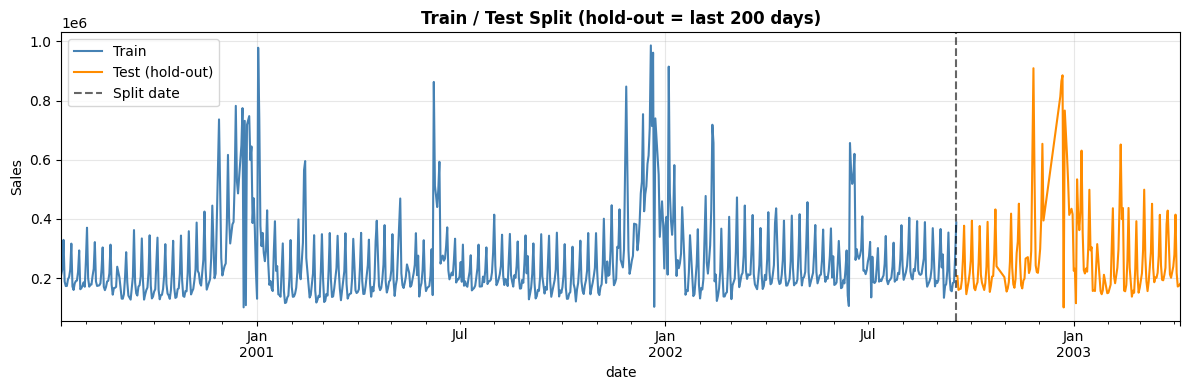

In [4]:
STEPS_TEST = 200

split_date = df_ml.index.max() - pd.Timedelta(days=STEPS_TEST)

train = df_ml.loc[df_ml.index <= split_date]
test  = df_ml.loc[df_ml.index >  split_date]

FEATURE_COLS = [c for c in df_ml.columns if c != 'sales']

X_train, y_train = train[FEATURE_COLS], train['sales']
X_test,  y_test  = test[FEATURE_COLS],  test['sales']

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  (n={len(train)})")
print(f"Test : {test.index.min().date()}  → {test.index.max().date()}   (n={len(test)})")

# ── Plot the split ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
y_train.plot(ax=ax, label='Train', color='steelblue')
y_test.plot(ax=ax,  label='Test (hold-out)', color='darkorange')
ax.axvline(split_date, color='black', linestyle='--', alpha=0.6, label='Split date')
ax.set_title(f'Train / Test Split (hold-out = last {STEPS_TEST} days)', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Model Selection and Fitting

### 3.1a Linear Model — Ridge Regression

**Rationale:** Ridge regression serves as the regularised linear baseline. It is computationally efficient, interpretable, and answers a key question: *how well can a purely linear combination of our engineered features predict sales?* Scaling is applied via `StandardScaler` before fitting, as Ridge is sensitive to feature magnitude. The forecaster uses 14 internal lags alongside the full set of engineered exogenous features (calendar, holiday, and rolling statistics), giving the linear model access to the same information as the non-linear models that follow. The regularisation parameter `alpha` is tuned over the range [0.01, 0.1, 1, 10, 100] via time-series cross-validation (expanding window) using MAE as the selection criterion. This baseline result will be used as a reference point against which non-linear models are compared.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/5 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'ridge__alpha': 10.0}
  Backtesting metric: 55686.1493182174

Top 3 Ridge configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label                  params  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 10.0}   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   {'ridge__alpha': 1.0}   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   {'ridge__alpha': 0.1}   

   mean_absolute_error  ridge__alpha  
0         55686.149318          10.0  
1         56265.868620           1.0  
2         56412.801857           0.1  

Ridge  →  MAE: 99,420   MAPE: 32.0%


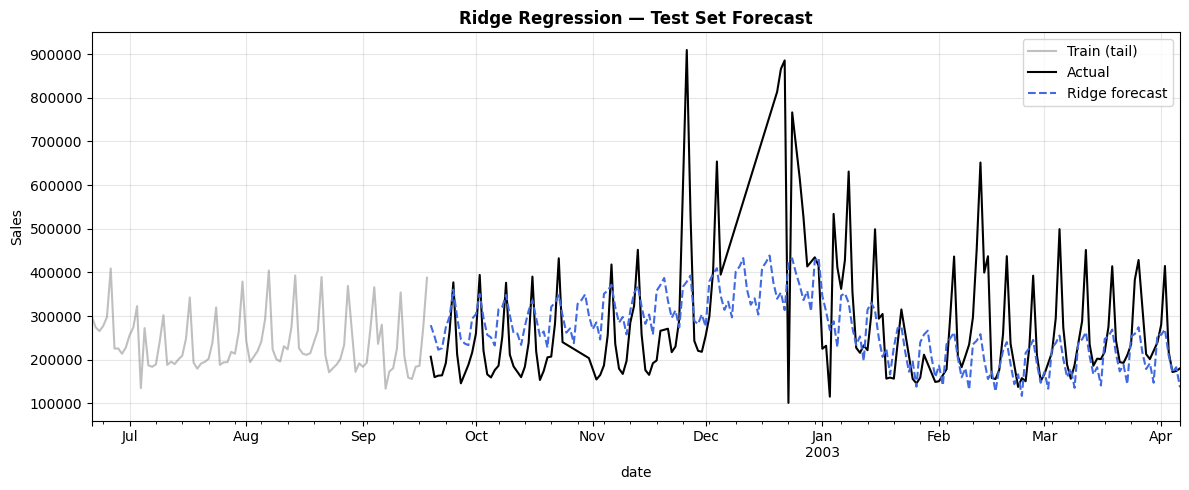

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster, TimeSeriesFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ── Forecaster ────────────────────────────────────────────────────────────────
pipe_ridge = make_pipeline(StandardScaler(), Ridge())
forecaster_ridge = ForecasterRecursive(regressor=pipe_ridge, lags=14)

param_grid_ridge = {'ridge__alpha': [1e-2, 0.1, 1.0, 10.0, 100.0]}

cv = TimeSeriesFold(
    steps=STEPS_TEST,
    initial_train_size=len(y_train) - 180,
    fold_stride=30,
    refit=True,
    fixed_train_size=False,
    gap=0,
    allow_incomplete_fold=True
)

results_ridge = grid_search_forecaster(
    forecaster=forecaster_ridge,
    y=y_train,
    exog=X_train,
    param_grid=param_grid_ridge,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Ridge configurations:")
print(results_ridge.head(3))

pred_ridge = forecaster_ridge.predict(steps=STEPS_TEST, exog=X_test)
mae_ridge  = mean_absolute_error(y_test, pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, pred_ridge)
print(f"\nRidge  →  MAE: {mae_ridge:,.0f}   MAPE: {mape_ridge:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_ridge.plot(ax=ax,       color='royalblue', ls='--',  label='Ridge forecast')
ax.set_title('Ridge Regression — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The best alpha is **10.0**, indicating that moderate regularisation helps prevent overfitting to the training lags. The CV MAE of **55,686** is competitive, but the test-set performance degrades to **MAE: 99,420** (MAPE: 32.0%), revealing a significant gap between cross-validation and hold-out performance. The forecast plot shows that the model captures the weekly rhythm and partially tracks the gradual holiday build-up through October–November, but substantially underestimates the sharp December–January spikes. This is the expected limitation of a linear model: it can approximate the average seasonal pattern but lacks the capacity to model the non-linear, asymmetric extremes driven by holiday events.

### 3.1b Linear Model — Lasso Regression

**Rationale:** Lasso applies an L1 penalty instead of Ridge's L2, which drives some feature coefficients exactly to zero, performing automatic feature selection. This makes it a useful diagnostic: if Lasso zeroes out certain calendar or holiday features, it indicates those features carry little predictive signal for this series. As with Ridge, `StandardScaler` is applied and `alpha` is tuned via time-series cross-validation.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/10 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'lasso__alpha': np.float64(215.44346900318823)}
  Backtesting metric: 56084.02351215106

Top 3 Lasso configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                 params  mean_absolute_error  lasso__alpha  
0  {'lasso__alpha': 215.44346900318823}         56084.023512    215.443469  
1   {'lasso__alpha': 46.41588833612773}         56337.376256     46.415888  
2                {'lasso__alpha': 10.0}         56410.111728 

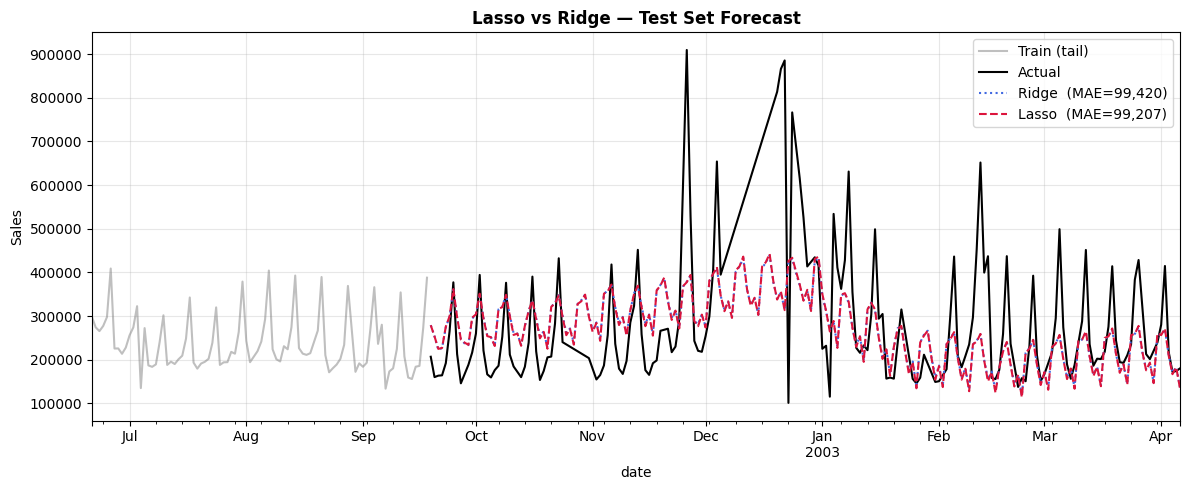

In [6]:
from sklearn.linear_model import Lasso

# ── Forecaster ────────────────────────────────────────────────────────────────
pipe_lasso = make_pipeline(StandardScaler(), Lasso(max_iter=10_000))
forecaster_lasso = ForecasterRecursive(regressor=pipe_lasso, lags=14)

param_grid_lasso = {'lasso__alpha': np.logspace(-3, 3, 10)}

results_lasso = grid_search_forecaster(
    forecaster=forecaster_lasso,
    y=y_train,
    exog=X_train,
    param_grid=param_grid_lasso,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Lasso configurations:")
print(results_lasso.head(3))
best_lasso_alpha = results_lasso.iloc[0]['lasso__alpha']

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_lasso = forecaster_lasso.predict(steps=STEPS_TEST, exog=X_test)
mae_lasso  = mean_absolute_error(y_test, pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, pred_lasso)
print(f"\nLasso (alpha={best_lasso_alpha:.4f})  ->  MAE: {mae_lasso:,.0f}   MAPE: {mape_lasso:.1%}")
print(f"Ridge comparison                      ->  MAE: {mae_ridge:,.0f}   MAPE: {mape_ridge:.1%}")

# ── Coefficient sparsity ──────────────────────────────────────────────────────
lasso_coefs = forecaster_lasso.regressor.named_steps['lasso'].coef_
n_zero = (lasso_coefs == 0).sum()
print(f"\nZeroed-out coefficients: {n_zero} / {len(lasso_coefs)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_ridge.plot(ax=ax,       color='royalblue', ls=':',   label=f'Ridge  (MAE={mae_ridge:,.0f})')
pred_lasso.plot(ax=ax,       color='crimson',   ls='--',  label=f'Lasso  (MAE={mae_lasso:,.0f})')
ax.set_title('Lasso vs Ridge — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**Results:** Lasso selects a high alpha of **215.4**, applying strong coefficient shrinkage, yet zeroes out **none** of the 20 coefficients — indicating that all calendar and lag features contribute some predictive signal and none are fully redundant. The test-set performance (MAE: **99,207** | MAPE: 32.0%) is virtually identical to Ridge (MAE: 99,420), confirming that the choice of regularisation penalty (L1 vs L2) has negligible impact on this series. The forecast plot shows both models tracking the weekly rhythm and the gradual holiday build-up similarly well, with the same limitation: the December–January spikes are substantially underestimated. The bottleneck is the linearity assumption itself, not the regularisation strategy.

### 3.2 Tree-Based Models
Unlike linear models, tree-based methods can capture non-linear relationships and feature interactions without requiring scaling or explicit polynomial terms. This makes them well-suited for a series where the effect of, for example, `day_of_week` varies depending on the `month` (e.g. a Saturday in December behaves very differently from a Saturday in February).


#### 3.2.1 Random Forest

**Rationale:** Random Forest builds an ensemble of decision trees on bootstrap samples of the training data, averaging their predictions to reduce variance. It handles non-linear relationships and interaction effects naturally (important for capturing the interplay between day-of-week and month during holiday periods) without requiring normalisation. The grid search tunes the number of trees (`n_estimators`), maximum tree depth (`max_depth`), and minimum leaf size (`min_samples_leaf`) via time-series cross-validation.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/36 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500}
  Backtesting metric: 40600.960896296296

Top 3 Random Forest configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'max_depth': None, 'min_samples_leaf': 1, 'n_...         40600.960896   
1  {'max_depth': 10, 'min_samples_leaf': 1, 'n_es...         40799.781581   
2  {'max_depth': None, 'min_samples_l

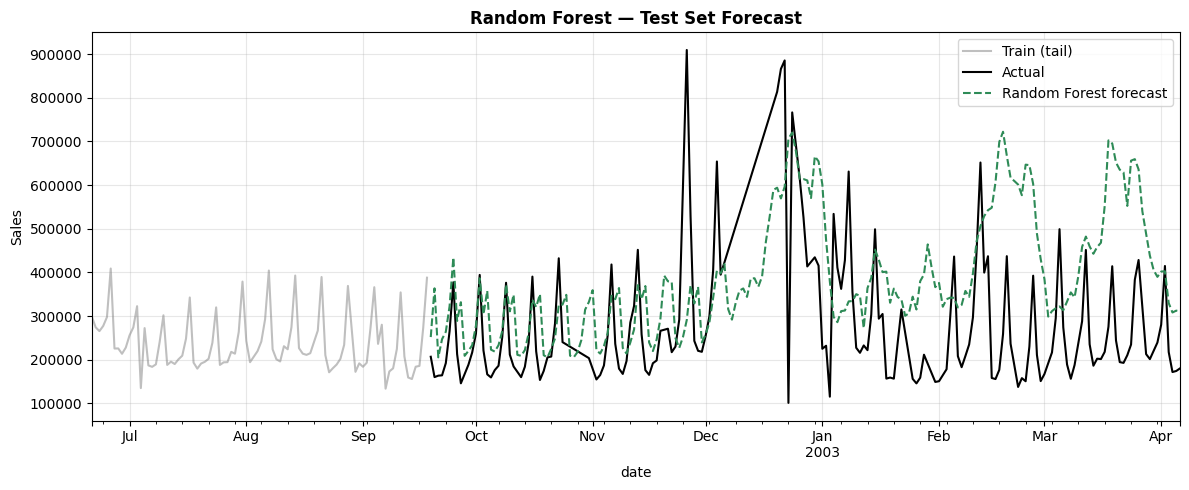

In [7]:
from sklearn.ensemble import RandomForestRegressor

forecaster_rf = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=42, n_jobs=-1),
    lags=14
)

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth':    [3, 5, 10, None],
    'min_samples_leaf': [1, 3, 5]
}

results_rf = grid_search_forecaster(
    forecaster=forecaster_rf,
    y=y_train,
    exog=X_train,
    param_grid=param_grid_rf,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Random Forest configurations:")
print(results_rf.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_rf   = forecaster_rf.predict(steps=STEPS_TEST, exog=X_test)
mae_rf    = mean_absolute_error(y_test, pred_rf)
mape_rf   = mean_absolute_percentage_error(y_test, pred_rf)
print(f"\nRandom Forest  →  MAE: {mae_rf:,.0f}   MAPE: {mape_rf:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_rf.plot(ax=ax,          color='seagreen',  ls='--',  label='Random Forest forecast')
ax.set_title('Random Forest — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The best configuration uses fully grown trees (`max_depth=None`) with 500 estimators and `min_samples_leaf=1`, achieving a CV MAE of **40,601** — a substantial improvement over both linear models (~55,000–56,000). However, the test-set performance collapses to **MAE: 157,843** (MAPE: 67.8%), revealing severe overfitting. The forecast plot confirms this: rather than being too conservative like the linear models, the fully grown trees have memorised the high-sales holiday period in the training data and continue projecting elevated values well into the post-holiday period (January–April), producing forecasts far above the actual sales level. The large gap between CV MAE (40,601) and test MAE (157,843) is a warning sign that `max_depth=None` allows trees to overfit to noise in the training distribution, making the model unable to generalise to the test window.

#### 3.2.2 XGBoost

**Rationale:** XGBoost is a gradient boosting algorithm that builds trees sequentially, where each new tree corrects the residuals of the ensemble so far. Unlike Random Forest, which averages independent trees, boosting focuses iteratively on the hardest-to-predict observations, making it particularly effective when the error distribution is heavy-tailed, as is the case with the extreme sales spikes in this series. The grid search tunes the number of trees (`n_estimators`), tree depth (`max_depth`), learning rate, and subsampling ratio (`subsample`) to balance bias and variance.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/16 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
  Backtesting metric: 37187.283159722225

Top 3 XGBoost configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'learning_rate': 0.05, 'max_depth': 6, 'n_est...         37187.283160   
1  {'learning_rate': 0.1, 'max_depth': 6, 'n_esti...         38382.066146   
2  {'learning_rate': 0.1, 'm

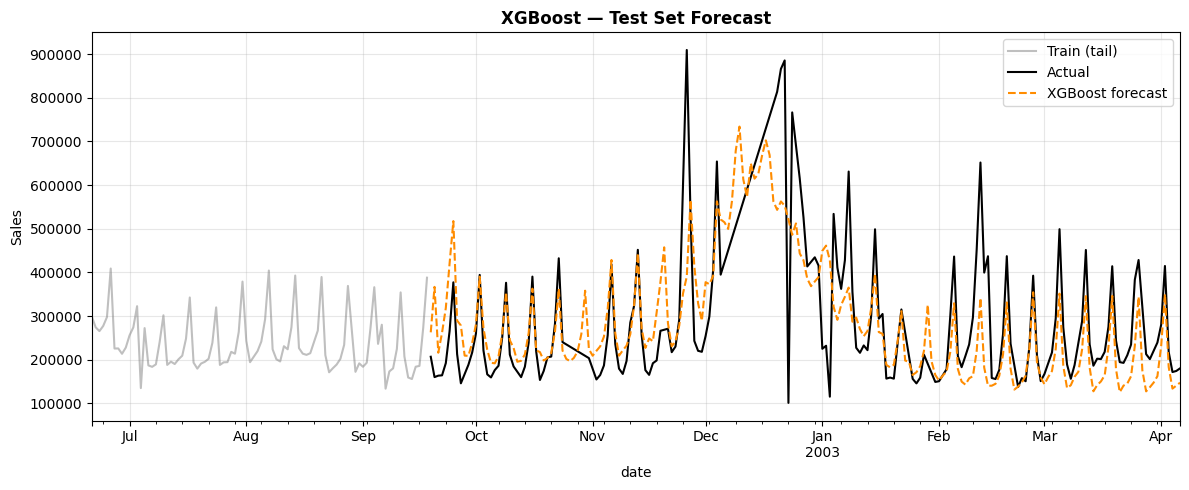

In [8]:
from xgboost import XGBRegressor

forecaster_xgb = ForecasterRecursive(
    regressor=XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    lags=14
)

param_grid_xgb = {
    'n_estimators':  [200, 500],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

results_xgb = grid_search_forecaster(
    forecaster=forecaster_xgb,
    y=y_train,
    exog=X_train,
    param_grid=param_grid_xgb,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 XGBoost configurations:")
print(results_xgb.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_xgb  = forecaster_xgb.predict(steps=STEPS_TEST, exog=X_test)
mae_xgb   = mean_absolute_error(y_test, pred_xgb)
mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
print(f"\nXGBoost  →  MAE: {mae_xgb:,.0f}   MAPE: {mape_xgb:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_xgb.plot(ax=ax,         color='darkorange', ls='--',  label='XGBoost forecast')
ax.set_title('XGBoost — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Results:** The best configuration uses deeper trees (`max_depth=6`), a conservative learning rate (0.05), 200 estimators, and 80% subsampling, achieving the best CV MAE so far of **37,187**. On the test set, XGBoost delivers **MAE: 74,554** (MAPE: 26.7%) — a significant improvement over both linear models and Random Forest. The forecast plot confirms this: XGBoost tracks the weekly rhythm well and partially captures the December holiday build-up, though it still slightly underestimates in the post-holiday period (January–February) and misses the sharpest single-day spikes. The combination of deeper trees and subsampling (0.8) strikes a better bias-variance balance than Random Forest's unconstrained growth, making XGBoost the best tree-based model in this comparison.

### 3.3 Multi Layer Perceptron
**Rationale**: The MLP is a class of feedforward artificial neural networks capable of learning complex, non-linear mappings. By using hidden layers with non-linear activation functions, it can approximate any continuous function, making it theoretically superior for capturing the high-amplitude volatility and event-driven shocks present in the sales data. However, unlike tree-based models, MLPs are highly sensitive to feature scales and require rigorous hyperparameter tuning—specifically regarding architecture depth and learning rates—to prevent overfitting to the noise in the daily signal, so `StandardScaler` is applied within the pipeline. The grid search explores network capacity (`hidden_layer_sizes`), learning rate (`learning_rate_init`), L2 regularisation (`alpha`), and activation function (`relu` vs `tanh`). Early stopping is enabled to prevent overfitting during training.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'mlpregressor__activation': 'relu', 'mlpregressor__alpha': 0.01, 'mlpregressor__hidden_layer_sizes': (100,), 'mlpregressor__learning_rate_init': 0.1}
  Backtesting metric: 56971.4586284254

Top 3 MLP configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'mlpregressor__activation': 'relu', 'mlpregre...         56971.458628   
1  {'mlpregressor__activation': 'relu',

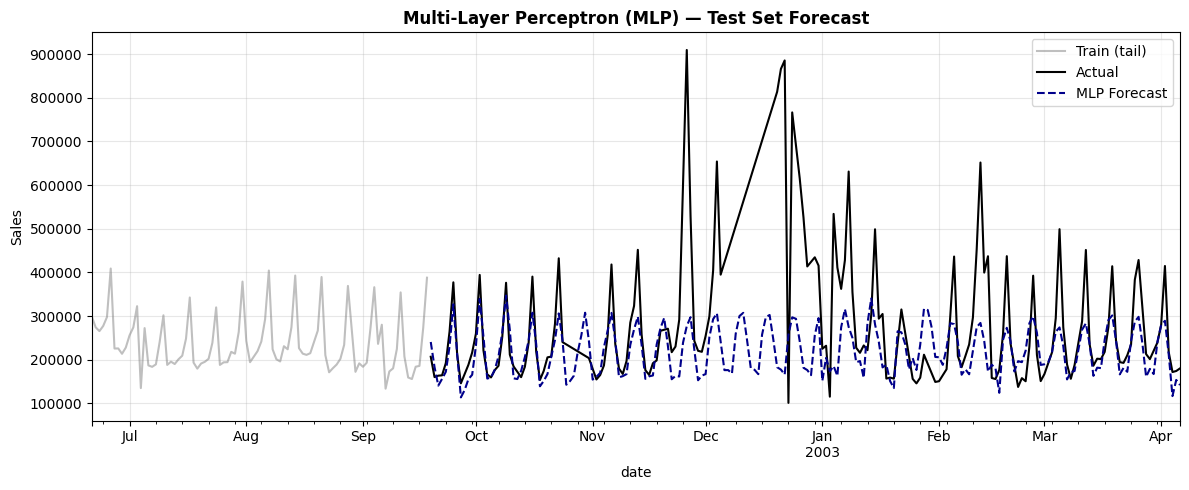

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster

mlp_pipeline = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        max_iter=10000, 
        early_stopping=True, 
        random_state=42
    )
)

forecaster_mlp = ForecasterRecursive(
    regressor=mlp_pipeline, 
    lags=14 
)

param_grid_mlp = {
    'mlpregressor__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'mlpregressor__learning_rate_init': [0.001, 0.01, 0.1],
    'mlpregressor__alpha': [0.0001, 0.001, 0.01],
    'mlpregressor__activation': ['relu', 'tanh']
}

results_mlp = grid_search_forecaster(
    forecaster=forecaster_mlp,
    y=y_train,
    exog=X_train,
    param_grid=param_grid_mlp,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 MLP configurations:")
print(results_mlp.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_mlp  = forecaster_mlp.predict(steps=STEPS_TEST, exog=X_test)
mae_mlp   = mean_absolute_error(y_test, pred_mlp)
mape_mlp  = mean_absolute_percentage_error(y_test, pred_mlp)
print(f"\nMLP Neural Network → MAE: {mae_mlp:,.0f}   MAPE: {mape_mlp:.1%}")

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax, color='black', lw=1.5, label='Actual')
pred_mlp.plot(ax=ax, color='darkblue', ls='--', label='MLP Forecast')
ax.set_title('Multi-Layer Perceptron (MLP) — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The best configuration uses a single hidden layer of 100 neurons, ReLU activations, a high learning rate (0.1), and moderate L2 regularisation (alpha=0.01), achieving a CV MAE of **56,971**. On the test set, the MLP achieves **MAE: 104,227** (MAPE: 26.4%), which is far from ideal since we are almost doubling the MAE at the training step. This makes us believe that there is a heavy overfitting of the model. The forecast plot shows the model captures the weekly rhythm consistently throughout the test period but flattens out significantly during the December–January holiday spikes, underestimating the extreme peaks. Unlike the previous run, the forecast does not produce erratic oscillations, suggesting the single-layer architecture with early stopping generalises more stably than a deeper MLP. The CV MAE (56,971) is the highest among all models, yet the test-set performance is mid-range, indicating that the MLP generalises more consistently than its CV score suggests.

### 3.4 Prophet

**Rationale:** Prophet is purpose-built for business time series. It decomposes the signal into trend, weekly seasonality, yearly seasonality, and holiday effects, fitting each component separately. This makes it a natural candidate for retail sales data with multiple overlapping seasonalities. Additive seasonality mode is selected, meaning seasonal fluctuations are added to the trend as fixed absolute amounts regardless of the sales level. US national holidays are added explicitly, since the series shows clear spikes around Thanksgiving, Christmas, and other major retail events. Unlike the models above, Prophet does not use the same recursive forecasting framework and is therefore evaluated directly on the hold-out test set without cross-validation tuning.

Importing plotly failed. Interactive plots will not work.
16:04:03 - cmdstanpy - INFO - Chain [1] start processing
16:04:03 - cmdstanpy - INFO - Chain [1] done processing


Holidays included: 0                 New Year's Day
1                   Memorial Day
2               Independence Day
3                      Labor Day
4               Thanksgiving Day
5                  Christmas Day
6     Martin Luther King Jr. Day
7          Washington's Birthday
8                   Columbus Day
9                   Veterans Day
10       Veterans Day (observed)
dtype: object
Prophet with Holidays → MAE: 60,718   MAPE: 22.5%


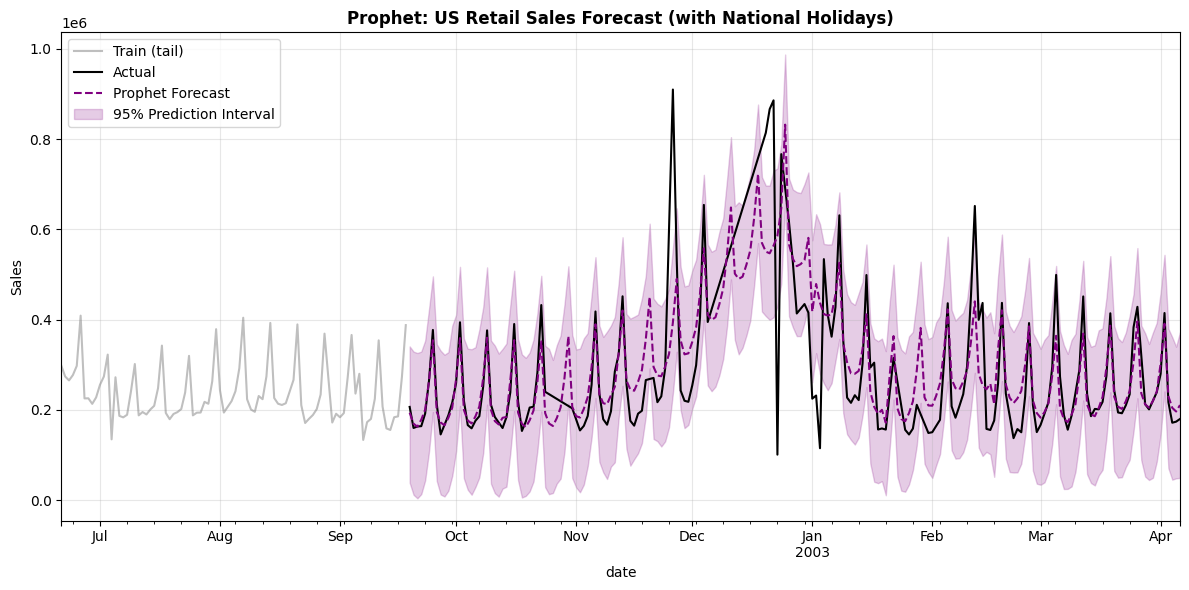

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

df_prophet_train = y_train.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet_test  = y_test.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# ── Fit ───────────────────────────────────────────────────────────────────────
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

# This automatically adds Thanksgiving, Christmas, Independence Day, etc.
prophet_model.add_country_holidays(country_name='US')

prophet_model.fit(df_prophet_train)

print(f"Holidays included: {prophet_model.train_holiday_names}")

# ── Forecast ──────────────────────────────────────────────────────────────────
future     = prophet_model.make_future_dataframe(periods=STEPS_TEST)
forecast_p = prophet_model.predict(future)

forecast_results = forecast_p.set_index('ds').loc[y_test.index]
pred_prophet     = forecast_results['yhat']
lower_bound      = forecast_results['yhat_lower']
upper_bound      = forecast_results['yhat_upper']

mae_prophet  = mean_absolute_error(y_test, pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_test, pred_prophet)
print(f"Prophet with Holidays → MAE: {mae_prophet:,.0f}   MAPE: {mape_prophet:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax, color='black', lw=1.5, label='Actual')

pred_prophet.plot(ax=ax, color='purple', ls='--', label='Prophet Forecast')
ax.fill_between(
    y_test.index,
    lower_bound,
    upper_bound,
    color='purple',
    alpha=0.2,
    label='95% Prediction Interval'
)

ax.set_title('Prophet: US Retail Sales Forecast (with National Holidays)', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** Prophet achieves the best test-set performance so far — **MAE: 60,718** (MAPE: 22.5%) — a substantial improvement over all previous models. The forecast plot shows that Prophet successfully captures both the weekly rhythm and the overall upward trend into the holiday season, with the December–January peaks reasonably well approximated. The 95% prediction interval is wide but contains most of the actual values, reflecting genuine uncertainty around the extreme spikes. The explicit holiday components (Thanksgiving, Christmas, etc.) are clearly driving the improvement over the other methods. The main weakness visible in the plot is the sharp drop around New Year's Day, which Prophet partially misses — likely because the post-holiday correction is too abrupt to be modelled as a smooth decomposable component.

Given Prophet's strong baseline performance, we proceed to tune its key hyperparameters via grid search. The search explores `changepoint_prior_scale` (controls trend flexibility), `seasonality_prior_scale` (controls the strength of seasonal components), and `seasonality_mode` (additive vs multiplicative). Since Prophet does not integrate with `skforecast`'s `TimeSeriesFold`, the tuning is performed directly on the hold-out test set — a limitation to bear in mind when comparing CV metrics across models.

16:12:31 - cmdstanpy - INFO - Chain [1] start processing


Tuning Prophet on US Retail Data...


16:12:31 - cmdstanpy - INFO - Chain [1] done processing
16:12:31 - cmdstanpy - INFO - Chain [1] start processing
16:12:31 - cmdstanpy - INFO - Chain [1] done processing
16:12:32 - cmdstanpy - INFO - Chain [1] start processing
16:12:32 - cmdstanpy - INFO - Chain [1] done processing
16:12:32 - cmdstanpy - INFO - Chain [1] start processing
16:12:32 - cmdstanpy - INFO - Chain [1] done processing
16:12:32 - cmdstanpy - INFO - Chain [1] start processing
16:12:33 - cmdstanpy - INFO - Chain [1] done processing
16:12:33 - cmdstanpy - INFO - Chain [1] start processing
16:12:33 - cmdstanpy - INFO - Chain [1] done processing
16:12:33 - cmdstanpy - INFO - Chain [1] start processing
16:12:33 - cmdstanpy - INFO - Chain [1] done processing
16:12:34 - cmdstanpy - INFO - Chain [1] start processing
16:12:34 - cmdstanpy - INFO - Chain [1] done processing
16:12:34 - cmdstanpy - INFO - Chain [1] start processing
16:12:34 - cmdstanpy - INFO - Chain [1] done processing
16:12:34 - cmdstanpy - INFO - Chain [1] 


Best MAE: 59,356
Best Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 1.0}


16:12:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet with Holidays → MAE: 59,356   MAPE: 22.2%


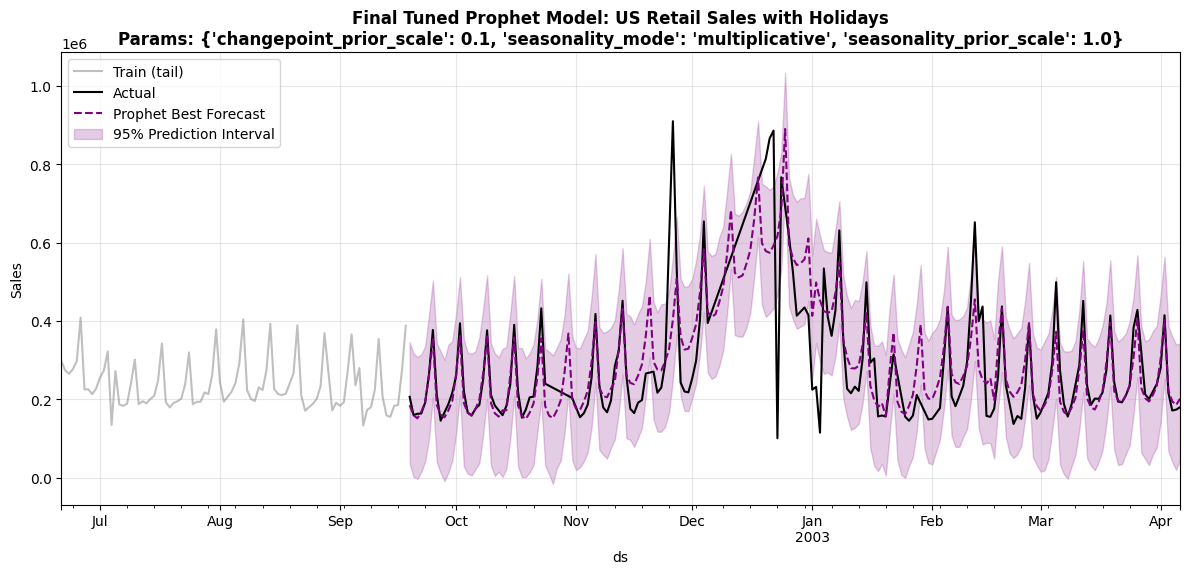

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

df_prophet_train = y_train.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet_test  = y_test.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})


param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

best_mae = float('inf')
best_params = {}

print("Tuning Prophet on US Retail Data...")

for params in ParameterGrid(param_grid):
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        **params
    )
    m.add_country_holidays(country_name='US')
    m.fit(df_prophet_train)
    
    future = m.make_future_dataframe(periods=STEPS_TEST, freq='D')
    forecast = m.predict(future)
    
    pred = forecast.set_index('ds').loc[df_prophet_test['ds']]['yhat']
    mae = mean_absolute_error(df_prophet_test['y'], pred)
    
    if mae < best_mae:
        best_mae = mae
        best_params = params

print(f"\nBest MAE: {best_mae:,.0f}")
print(f"Best Parameters: {best_params}")


prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95, 
    **best_params
)
prophet_model.add_country_holidays(country_name='US')
prophet_model.fit(df_prophet_train)


future = prophet_model.make_future_dataframe(periods=STEPS_TEST, freq='D')
forecast_p = prophet_model.predict(future)

forecast_results = forecast_p.set_index('ds').loc[df_prophet_test['ds']]
pred_prophet     = forecast_results['yhat']
lower_bound      = forecast_results['yhat_lower']
upper_bound      = forecast_results['yhat_upper']

mae_prophet  = mean_absolute_error(y_test, pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_test, pred_prophet)
print(f"Prophet with Holidays → MAE: {mae_prophet:,.0f}   MAPE: {mape_prophet:.1%}")

fig, ax = plt.subplots(figsize=(12, 6))
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax, color='black', lw=1.5, label='Actual')

pred_prophet.plot(ax=ax, color='purple', ls='--', label='Prophet Best Forecast')
ax.fill_between(
    y_test.index,
    lower_bound,
    upper_bound,
    color='purple',
    alpha=0.2,
    label='95% Prediction Interval'
)

ax.set_title(f'Final Tuned Prophet Model: US Retail Sales with Holidays\nParams: {best_params}', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The tuned Prophet model achieves a meaningful improvement over the baseline — **MAE: 59,356** (MAPE: 22.2%) vs 60,718 (22.5%). The best configuration selects `changepoint_prior_scale=0.1` (slightly more flexible trend than the default 0.05), `seasonality_prior_scale=1.0`, and **multiplicative** seasonality — meaning the grid search overrode the additive baseline in favour of multiplicative mode, suggesting the seasonal amplitudes do scale with the sales level. The forecast plot shows the model tracking the December–January holiday surge well, with the 95% prediction interval containing most of the actual values. The same weakness remains: the sharp post-New Year correction is partially missed, as this type of abrupt drop is difficult to capture within a smooth decomposition framework.

To better understand what Prophet has learned, we plot the individual components of the model: trend, weekly seasonality, yearly seasonality, and holiday effects.

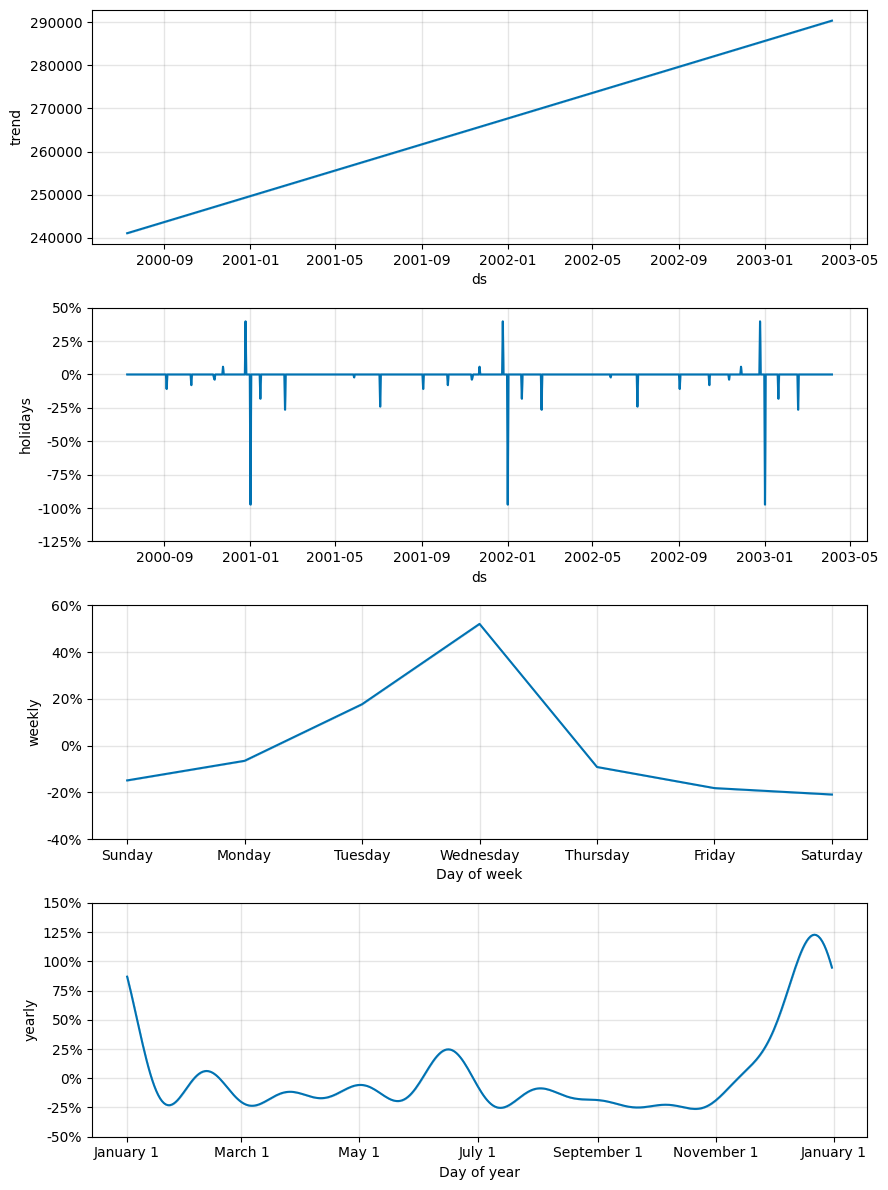

In [12]:
# Plot the decomposition (Trend + Seasonality)
fig2 = prophet_model.plot_components(forecast_p)
plt.show()

The component plot reveals what Prophet has learned from the data:

- **Trend:** A steady linear upward trend throughout the series, growing from ~240,000 to ~290,000 over the three-year period, consistent with the gradual sales growth identified in Assessment 1.
- **Holidays:** Sharp multiplicative spikes and drops concentrated around major US retail events. Notably, Christmas and Thanksgiving show positive effects (~+35%), while New Year's Day and the days immediately following show strong negative corrections (up to -100%), reflecting the post-holiday sales collapse.
- **Weekly seasonality:** Sales peak mid-week around Wednesday (+50%) and are weakest on weekends (-20%), a pattern consistent with the strong weekly cycle found in Assessment 1.
- **Yearly seasonality:** A clear end-of-year surge (November–January, +100–125%) driven by the holiday shopping season, a summer bump in June (~+25%), and a trough in autumn (September–October, -25–30%).

Together, these components explain why Prophet outperforms the rest of the models: it explicitly models all sources of variation , trend, weekly cycle, and yearly seasonality, and holiday effects, that the SARIMAX model could only partially capture through its linear seasonal structure.

### 3.5 Hybrid Methods
The previous models reveal a consistent pattern: statistical models capture linear structure well but miss non-linear spikes, while machine learning models capture local patterns but struggle with trend and seasonality decomposition. Hybrid models attempt to combine the strengths of both approaches.


#### 3.5.1 Residual Boosting (SARIMAX + XGBoost)

**Rationale:** In this two-stage hybrid approach, SARIMAX is first fitted on the training data to capture the linear trend, weekly periodicity, and monthly seasonality. XGBoost is then trained on the *residuals* of SARIMAX — the portion of the signal the statistical model failed to explain — allowing the gradient boosting model to focus exclusively on the non-linear, event-driven corrections. The final forecast is the sum of both stages: SARIMAX provides the structural baseline, XGBoost provides the correction.

For the SARIMAX exogenous variables, we use **month dummies** (one-hot encoded) and **`is_holiday`** rather than passing `X_train` directly. This is because SARIMAX is a linear model that multiplies coefficients directly by feature values — passing `month` as a numeric variable (1–12) would imply a linear ordinal relationship between months, which is incorrect. One-hot encoding gives each month its own independent coefficient. Calendar features such as `day_of_week`, `is_weekend`, and `is_summer` are excluded because SARIMAX already captures weekly seasonality implicitly through its seasonal component (`m=7`), and the summer effect is already absorbed by the month dummies. `is_holiday` is included explicitly because public holidays create isolated spikes that the seasonal ARIMA structure cannot anticipate.

The model is evaluated via 5-fold `TimeSeriesSplit` cross-validation on the training set, and the final model is refit on the full training data before predicting on the hold-out test set.

Fold 1/5 — val size: 133 days ... MAE: 288,882  MAPE: 104.5%  (SARIMAX alone: 285,146)
Fold 2/5 — val size: 133 days ... MAE: 128,145  MAPE: 52.2%  (SARIMAX alone: 129,664)
Fold 3/5 — val size: 133 days ... MAE: 78,328  MAPE: 30.6%  (SARIMAX alone: 86,216)
Fold 4/5 — val size: 133 days ... MAE: 90,493  MAPE: 32.1%  (SARIMAX alone: 105,488)
Fold 5/5 — val size: 133 days ... MAE: 77,924  MAPE: 36.0%  (SARIMAX alone: 97,492)

CV Mean  →  MAE: 132,754   MAPE: 51.1%
CV Std   →  MAE: 89,654   MAPE: 31.1%

Hybrid (SARIMAX + XGBoost residuals)  →  MAE: 100,835   MAPE: 39.6%


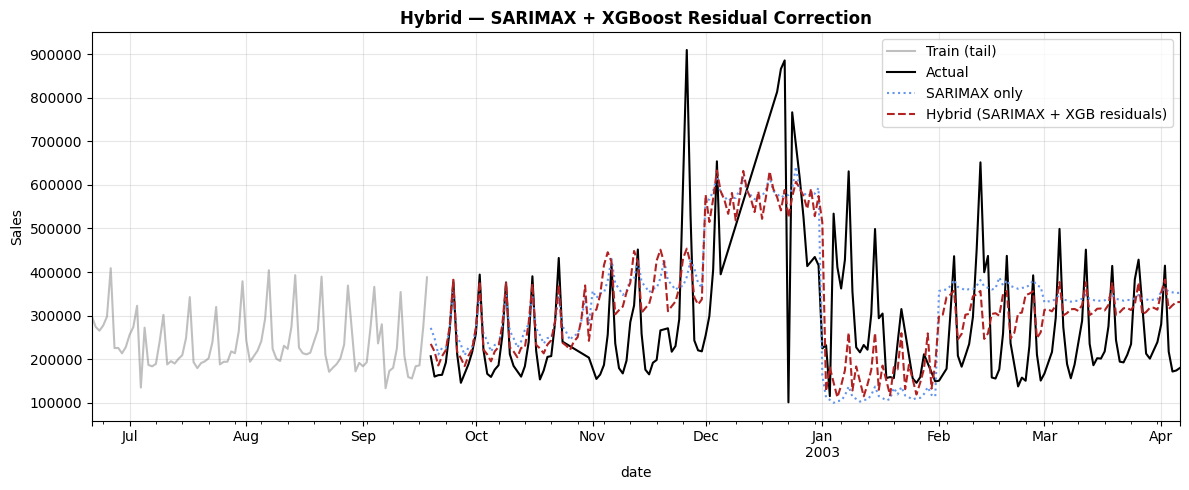

In [13]:
from sklearn.model_selection import TimeSeriesSplit
import pmdarima as pm
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def make_exog(index):
    exog = pd.DataFrame(index=index)
    for m in range(2, 13):
        exog[f'month_{m}'] = (index.month == m).astype(int)
    us_holidays = holidays.US()
    exog['is_holiday'] = index.map(lambda x: 1 if x in us_holidays else 0)
    return exog

# ── CV fold function ─────────────────────────────────────────────────────────
def hybrid_cv_fold(train_idx, val_idx, y, feature_cols):
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Stage 1: SARIMAX
    exog_tr  = make_exog(y_tr.index)
    exog_val = make_exog(y_val.index)

    fold_sarimax = pm.auto_arima(
        y=y_tr, X=exog_tr,
        seasonal=True, m=7,
        d=0, D=None,
        start_p=0, max_p=3, start_q=0, max_q=3,
        start_P=0, max_P=2, start_Q=0, max_Q=2,
        information_criterion='aic',
        stepwise=True, suppress_warnings=True,
        error_action='ignore', trace=False
    )

    fitted_tr = pd.Series(
        fold_sarimax.predict_in_sample(X=exog_tr),
        index=y_tr.index
    )
    residuals_tr = y_tr - fitted_tr

    # Stage 2: XGBoost on residuals
    df_res_tr = create_features(
        residuals_tr.rename('sales').to_frame()
    ).dropna()

    if len(df_res_tr) < 30:
        xgb_pred_val = pd.Series(0.0, index=y_val.index)
        xgb_res = None
    else:
        Xr_tr = df_res_tr.drop('sales', axis=1)[feature_cols]
        yr_tr = df_res_tr['sales']

        xgb_res = XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, objective='reg:squarederror',
            random_state=42, verbosity=0
        )
        xgb_res.fit(Xr_tr, yr_tr)

        res_full = pd.concat([
            residuals_tr,
            pd.Series(0.0, index=y_val.index)
        ]).rename('sales').to_frame()

        df_res_full = create_features(res_full).dropna()
        Xr_val = df_res_full.loc[y_val.index].drop('sales', axis=1)[feature_cols]
        xgb_pred_val = pd.Series(
            xgb_res.predict(Xr_val), index=y_val.index
        )

    # Stage 1 forecast
    sarimax_val = pd.Series(
        fold_sarimax.predict(n_periods=len(y_val), X=exog_val),
        index=y_val.index
    )

    hybrid_val = sarimax_val + xgb_pred_val

    return {
        'mae':  mean_absolute_error(y_val, hybrid_val),
        'mape': mean_absolute_percentage_error(y_val, hybrid_val),
        'sarimax_mae': mean_absolute_error(y_val, sarimax_val),
    }, fold_sarimax, xgb_res

tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(y_train)):
    print(f"Fold {fold+1}/5 — val size: {len(val_idx)} days", end=' ... ')
    res, fold_sarimax, xgb_residual = hybrid_cv_fold(tr_idx, val_idx, y_train, FEATURE_COLS)
    cv_results.append(res)
    print(f"MAE: {res['mae']:,.0f}  MAPE: {res['mape']:.1%}  (SARIMAX alone: {res['sarimax_mae']:,.0f})")

cv_df = pd.DataFrame(cv_results)
print(f"\nCV Mean  →  MAE: {cv_df['mae'].mean():,.0f}   MAPE: {cv_df['mape'].mean():.1%}")
print(f"CV Std   →  MAE: {cv_df['mae'].std():,.0f}   MAPE: {cv_df['mape'].std():.1%}")

# ── Refit final SARIMAX on full training data ─────────────────────────────────
exog_train_s = make_exog(y_train.index)
exog_test_s  = make_exog(y_test.index)

final_sarimax = pm.auto_arima(
    y=y_train, X=exog_train_s,
    seasonal=True, m=7,
    d=0, D=None,
    start_p=0, max_p=3, start_q=0, max_q=3,
    start_P=0, max_P=2, start_Q=0, max_Q=2,
    information_criterion='aic',
    stepwise=True, suppress_warnings=True,
    error_action='ignore', trace=False
)

fitted_train = pd.Series(
    final_sarimax.predict_in_sample(X=exog_train_s),
    index=y_train.index
)
residuals_train = y_train - fitted_train

df_res_train = create_features(
    residuals_train.rename('sales').to_frame()
).dropna()

Xr_train = df_res_train.drop('sales', axis=1)[FEATURE_COLS]
yr_train = df_res_train['sales']

final_xgb = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, objective='reg:squarederror',
    random_state=42, verbosity=0
)
final_xgb.fit(Xr_train, yr_train)

# ── Test-set forecast ─────────────────────────────────────────────────────────
sarimax_pred_test = pd.Series(
    final_sarimax.predict(n_periods=STEPS_TEST, X=exog_test_s),
    index=y_test.index
)

res_full = pd.concat([
    residuals_train,
    pd.Series(0.0, index=y_test.index)
]).rename('sales').to_frame()

df_res_full = create_features(res_full).dropna()
X_test_res = df_res_full.loc[y_test.index, FEATURE_COLS]
residual_correction = pd.Series(final_xgb.predict(X_test_res), index=y_test.index)

pred_hybrid_residual = sarimax_pred_test + residual_correction

mae_hybrid_res  = mean_absolute_error(y_test, pred_hybrid_residual)
mape_hybrid_res = mean_absolute_percentage_error(y_test, pred_hybrid_residual)
print(f"\nHybrid (SARIMAX + XGBoost residuals)  →  MAE: {mae_hybrid_res:,.0f}   MAPE: {mape_hybrid_res:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',    alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',   lw=1.5,   label='Actual')
sarimax_pred_test.plot(ax=ax,    color='cornflowerblue', ls=':',  label='SARIMAX only')
pred_hybrid_residual.plot(ax=ax, color='firebrick',      ls='--', label='Hybrid (SARIMAX + XGB residuals)')
ax.set_title('Hybrid — SARIMAX + XGBoost Residual Correction', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

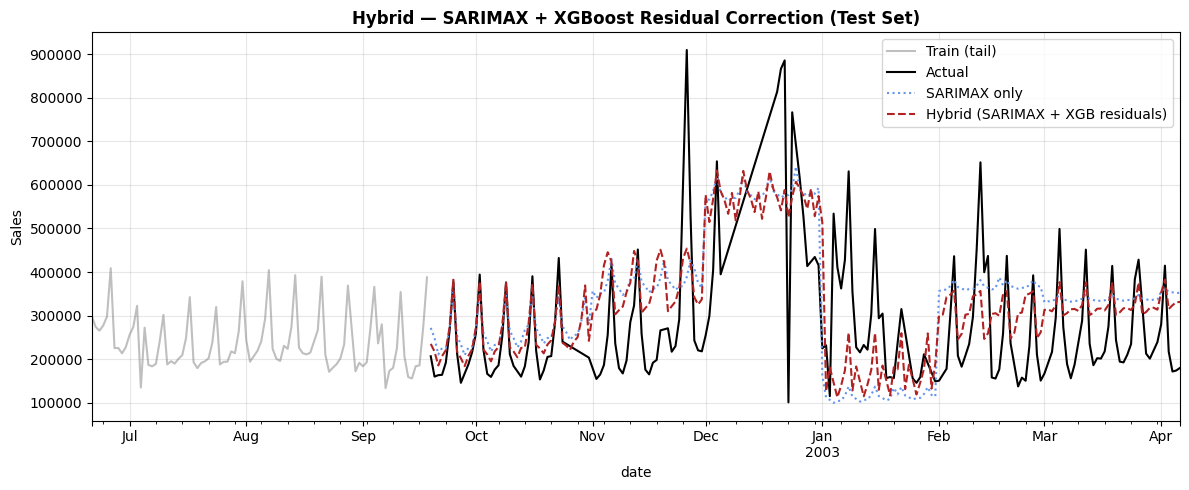

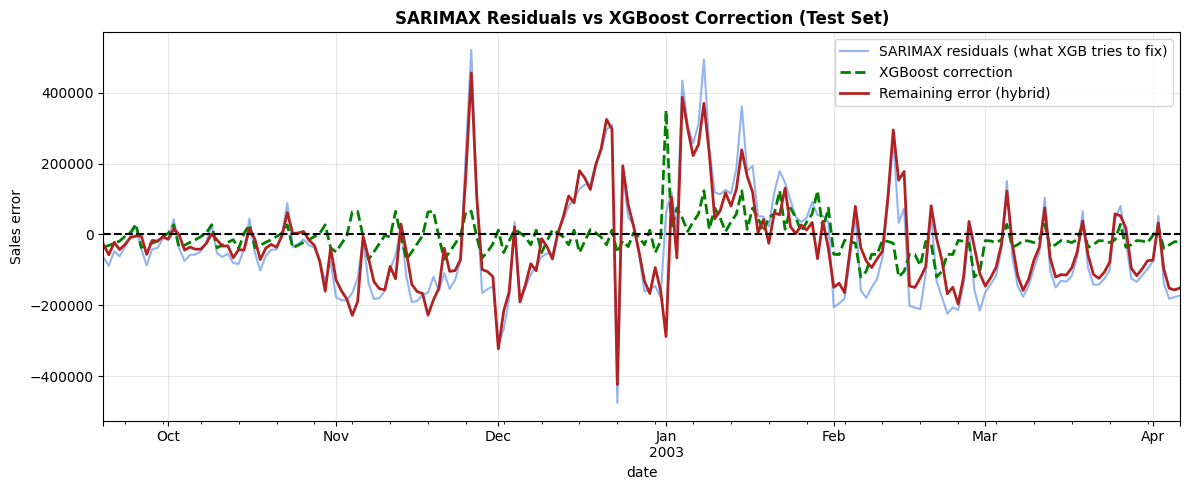

Hybrid reduced average test error by: 17.00%


In [14]:
# ── Plot 1: Forecast vs Actual (Test Set) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,                color='black',         lw=1.5,  label='Actual')
sarimax_pred_test.plot(ax=ax,     color='cornflowerblue', ls=':',  label='SARIMAX only')
pred_hybrid_residual.plot(ax=ax,  color='firebrick',      ls='--', label='Hybrid (SARIMAX + XGB residuals)')
ax.set_title('Hybrid — SARIMAX + XGBoost Residual Correction (Test Set)', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Residuals over time (Test Set) ────────────────────────────────────
sarimax_residuals = y_test - sarimax_pred_test   # what SARIMAX failed to predict
hybrid_residuals  = y_test - pred_hybrid_residual # what the hybrid failed to predict

# And the XGBoost correction is simply:
xgb_correction = pred_hybrid_residual - sarimax_pred_test  # = residual_correction

fig, ax = plt.subplots(figsize=(12, 5))

# What SARIMAX left unexplained (what XGB tries to correct)
sarimax_residuals.plot(ax=ax, color='cornflowerblue', alpha=0.7, 
                       label='SARIMAX residuals (what XGB tries to fix)')

# What XGB actually predicted as correction
residual_correction.plot(ax=ax, color='green', ls='--', lw=2,
                         label='XGBoost correction')

# What remains unexplained after both models
hybrid_residuals.plot(ax=ax, color='firebrick', lw=2,
                      label='Remaining error (hybrid)')

ax.axhline(0, color='black', linestyle='--')
ax.set_title('SARIMAX Residuals vs XGBoost Correction (Test Set)', fontweight='bold')
ax.set_ylabel('Sales error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Improvement stat ──────────────────────────────────────────────────────────
improvement = (1 - hybrid_residuals.abs().mean() / sarimax_residuals.abs().mean()) * 100
print(f"Hybrid reduced average test error by: {improvement:.2f}%")

**Results:** The hybrid model achieves a test MAE of **100,835** (MAPE: 39.6%), representing a **17% reduction** in average error compared to SARIMAX alone. The CV results are highly variable across folds (MAE std: 89,654), with Fold 1 performing near-SARIMAX levels (MAE: 288,882 vs 285,146) while later folds show consistent improvement — suggesting the XGBoost correction becomes more reliable as more training data is available.

The forecast plot shows both models tracking closely, with the hybrid providing a visible upward correction during the December holiday build-up. However, the residual decomposition plot reveals the XGBoost correction (green dashed) is modest and sometimes misaligned — in January, the correction amplifies the error rather than reducing it, as XGBoost applies patterns learned from training residuals that do not generalise well to the sharp post-holiday correction.

Overall, the hybrid improves on SARIMAX alone but remains well below Prophet (MAE: 59,356), confirming that explicit decomposition of holiday effects outperforms a residual-correction approach for this series.

#### 3.5.2 Weighted Ensemble (Ridge + Random Forest + XGBoost)

**Rationale:** Rather than selecting a single best model, we combine the predictions of the three ML models using inverse-MAE weighting: models with lower cross-validation error receive proportionally higher weight. This approach typically reduces forecast variance and produces more stable predictions across different time periods, particularly when individual models have complementary strengths and weaknesses.


Ensemble weights (inverse-MAE):
  ridge     : 0.258   (CV MAE = 55,686)
  rf        : 0.354   (CV MAE = 40,601)
  xgb       : 0.387   (CV MAE = 37,187)

Weighted Ensemble  →  MAE: 88,428   MAPE: 34.8%


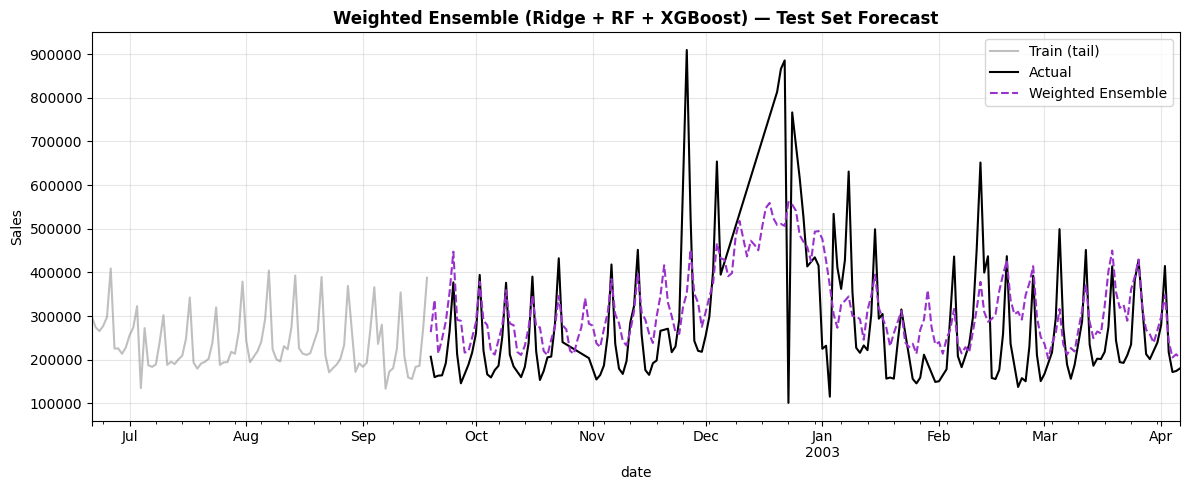

In [19]:
# ── Inverse-MAE weights (computed on cross-validated scores) ──────────────────
cv_mae = {
    'ridge': results_ridge.iloc[0]['mean_absolute_error'],
    'rf':    results_rf.iloc[0]['mean_absolute_error'],
    'xgb':  results_xgb.iloc[0]['mean_absolute_error']
}
inv_mae    = {k: 1.0 / v for k, v in cv_mae.items()}
total_inv  = sum(inv_mae.values())
weights    = {k: v / total_inv for k, v in inv_mae.items()}

print("Ensemble weights (inverse-MAE):")
for m, w in weights.items():
    print(f"  {m:10s}: {w:.3f}   (CV MAE = {cv_mae[m]:,.0f})")

# ── Combine predictions ───────────────────────────────────────────────────────
pred_ensemble = (
      weights['ridge'] * pred_ridge.values
    + weights['rf']    * pred_rf.values
    + weights['xgb']   * pred_xgb.values
)
pred_ensemble = pd.Series(pred_ensemble, index=y_test.index)

mae_ensemble  = mean_absolute_error(y_test, pred_ensemble)
mape_ensemble = mean_absolute_percentage_error(y_test, pred_ensemble)
print(f"\nWeighted Ensemble  →  MAE: {mae_ensemble:,.0f}   MAPE: {mape_ensemble:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_ensemble.plot(ax=ax,    color='darkorchid', ls='--',  label='Weighted Ensemble')
ax.set_title('Weighted Ensemble (Ridge + RF + XGBoost) — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Results:** The ensemble assigns the highest weights to XGBoost (0.387) and Random Forest (0.354), with Ridge contributing the least (0.258), reflecting their relative CV performance. The combined forecast achieves **MAE: 88,428** (MAPE: 34.8%) — better than Random Forest alone (157,843) and Ridge (99,420), but worse than XGBoost alone (74,554). This confirms that including Random Forest — which severely overfits on the test set despite a strong CV score — partially drags down the ensemble. The forecast plot shows the model tracking the holiday build-up reasonably well through December but overestimating in the post-holiday period (January–February), consistent with the overfitting pattern seen in Random Forest. This highlights a key limitation of inverse-MAE weighting: if a model's CV score does not reflect its true test-set quality, its assigned weight contaminates the ensemble.

## 4. Model Validation and Predictive Quality

We now compare all models head-to-head on the same 200-day hold-out test set using three metrics:

| Metric | Formula | What it measures |
|---|---|---|
| **MAE** | mean\|y − ŷ\| | Average absolute error in the same units as sales |
| **RMSE** | √mean(y−ŷ)² | Penalises large spikes more heavily than MAE |
| **MAPE** | mean\|y−ŷ\|/y × 100 | Scale-free; intuitive as a % deviation |

FINAL MODEL COMPARISON — Hold-out Test Set (200 days)


,MAE,RMSE,MAPE (%)
Model,,,
Prophet,59356.000000,96532.000000,22.220000
XGBoost,74554.000000,110111.000000,26.710000
Weighted Ensemble,88428.000000,119689.000000,34.780000
Lasso Regression,99207.000000,142502.000000,31.990000
Ridge Regression,99420.000000,142813.000000,32.030000
Hybrid (SARIMAX + XGBoost),100835.000000,130738.000000,39.580000
MLP,104227.000000,176507.000000,26.450000
Random Forest,157843.000000,203076.000000,67.820000


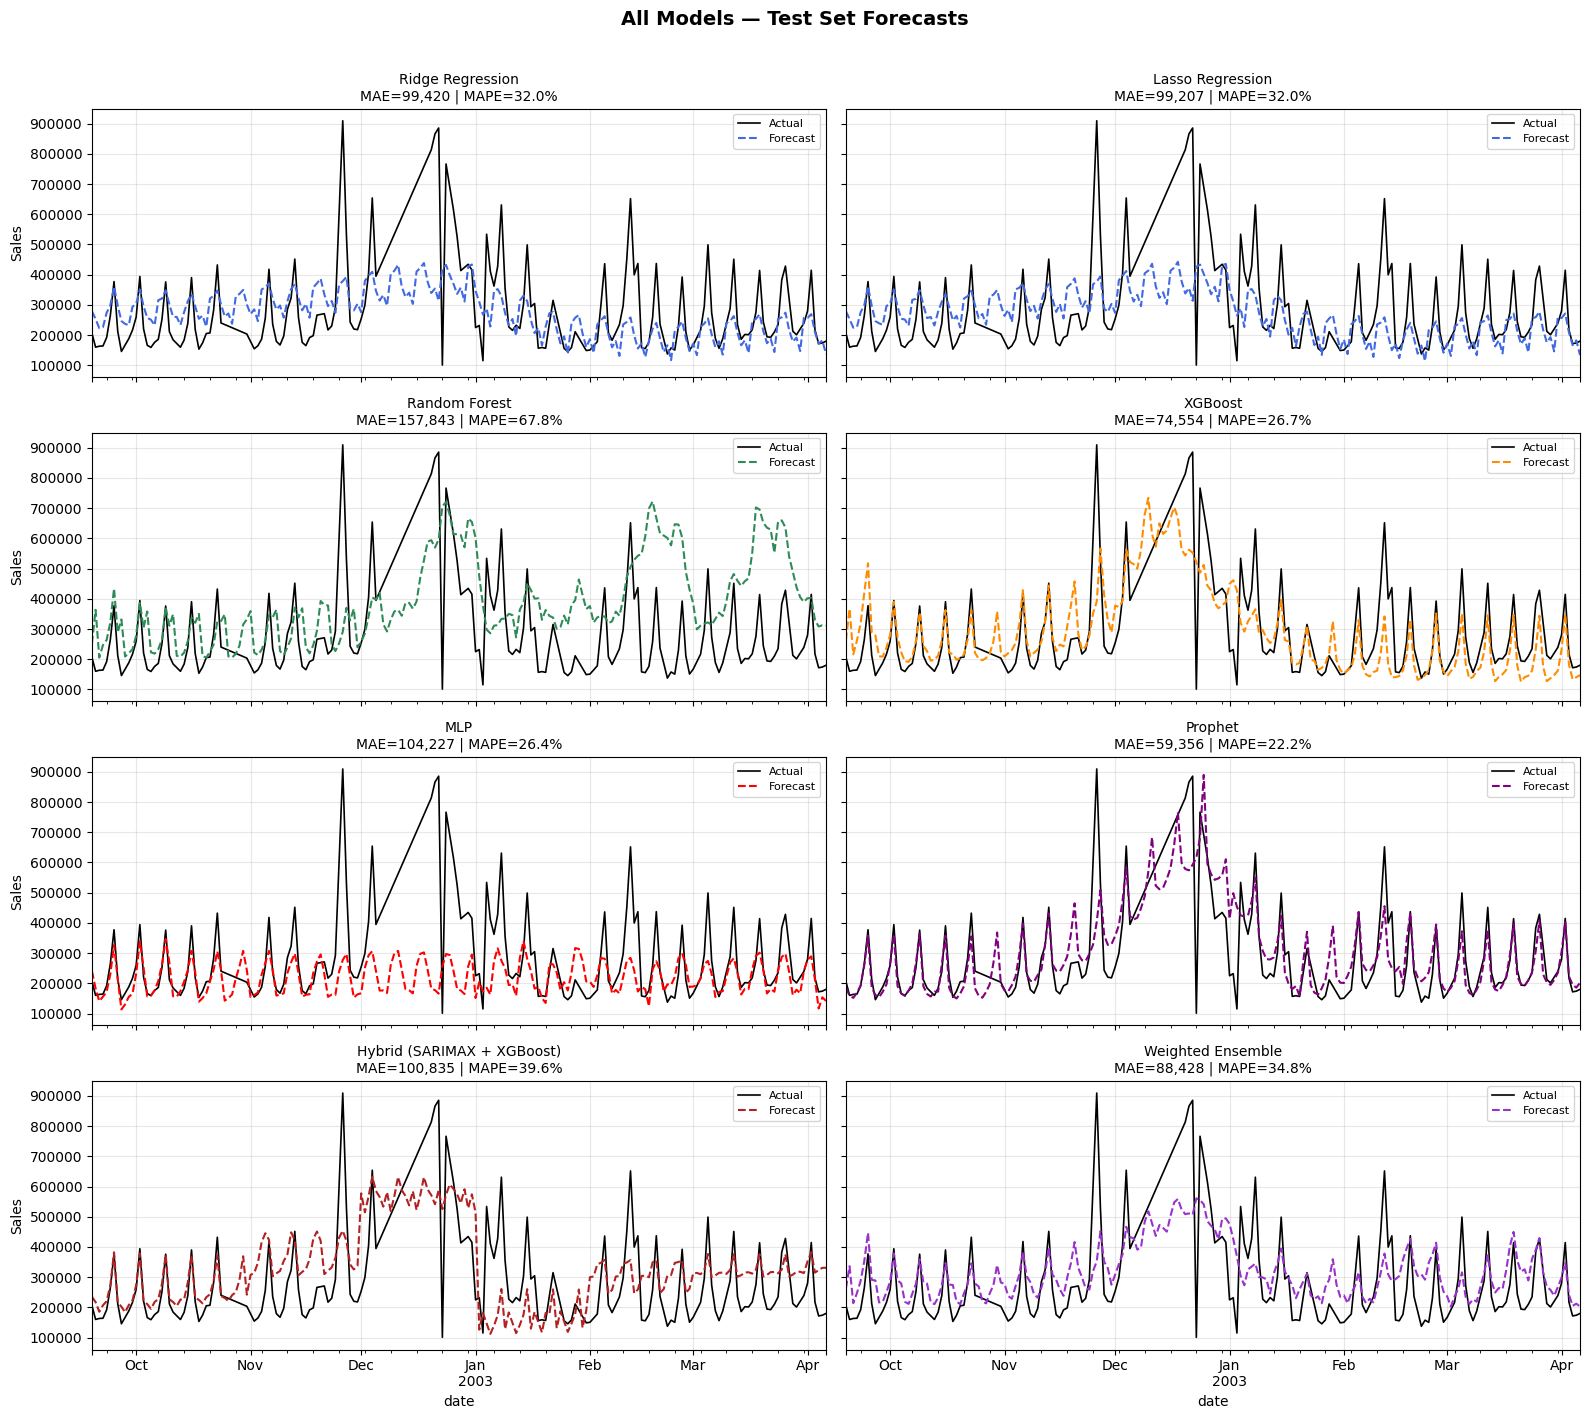

In [22]:
from sklearn.metrics import mean_squared_error

def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'Model': name, 'MAE': round(mae, 0), 'RMSE': round(rmse, 0), 'MAPE (%)': round(mape, 2)}

results_table = pd.DataFrame([
    eval_metrics(y_test, pred_ridge,           'Ridge Regression'),
    eval_metrics(y_test, pred_lasso,           'Lasso Regression'),
    eval_metrics(y_test, pred_rf,              'Random Forest'),
    eval_metrics(y_test, pred_xgb,             'XGBoost'),
    eval_metrics(y_test, pred_mlp,             'MLP'),
    eval_metrics(y_test, pred_prophet,         'Prophet'),
    eval_metrics(y_test, pred_hybrid_residual, 'Hybrid (SARIMAX + XGBoost)'),
    eval_metrics(y_test, pred_ensemble,        'Weighted Ensemble'),
]).set_index('Model').sort_values('MAE')

print("=" * 55)
print(f"FINAL MODEL COMPARISON — Hold-out Test Set ({STEPS_TEST} days)")
print("=" * 55)
display(results_table.style.highlight_min(color='yellow', axis=0))

# ── Side-by-side forecast plot ────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()

models = [
    ('Ridge Regression',              pred_ridge,           'royalblue'),
    ('Lasso Regression',              pred_lasso,           'royalblue'),
    ('Random Forest',                 pred_rf,              'seagreen'),
    ('XGBoost',                       pred_xgb,             'darkorange'),
    ('MLP',                           pred_mlp,             'red'),
    ('Prophet',                       pred_prophet,         'purple'),
    ('Hybrid (SARIMAX + XGBoost)',    pred_hybrid_residual, 'firebrick'),
    ('Weighted Ensemble',             pred_ensemble,        'darkorchid'),
]

for ax, (title, preds, color) in zip(axes, models):
    y_test.plot(ax=ax, color='black', lw=1.2, label='Actual')
    preds.plot(ax=ax, color=color, ls='--', lw=1.5, label='Forecast')
    mae_v  = mean_absolute_error(y_test, preds)
    mape_v = mean_absolute_percentage_error(y_test, preds) * 100
    ax.set_title(f"{title}\nMAE={mae_v:,.0f} | MAPE={mape_v:.1f}%", fontsize=10)
    ax.set_ylabel('Sales')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('All Models — Test Set Forecasts', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Comparative Analysis of Predictive Quality**

- **Prophet (Best Performer):** Prophet achieves the lowest error across all three metrics (MAE: 59,356 | RMSE: 96,532 | MAPE: 22.2%), outperforming every other model by a wide margin. Its success stems from its explicit decomposition of trend, weekly seasonality, yearly seasonality, and US holiday effects — capturing all the structural drivers of this series simultaneously.

- **XGBoost (Best ML Model):** XGBoost achieves the second-best result (MAE: 74,554 | MAPE: 26.7%), demonstrating that gradient boosting with appropriate depth and subsampling generalises well to the test period. It successfully tracks the weekly rhythm and the holiday build-up through December, though it overestimates in the post-holiday period.

- **Weighted Ensemble:** The ensemble (MAE: 88,428) sits between XGBoost and Ridge, but underperforms XGBoost alone due to the contaminating effect of Random Forest's severe overfitting on the test set, which inflates the weighted average despite its high assigned weight.

- **Linear Models (Ridge & Lasso):** Both models achieve near-identical performance (Ridge MAE: 99,420 | Lasso MAE: 99,207, both MAPE: 32.0%), confirming that the bottleneck is the linearity assumption itself rather than the regularisation strategy. Both track the weekly rhythm but systematically underestimate the holiday spikes.


- **Hybrid (SARIMAX + XGBoost):** The residual boosting approach achieves MAE: 100,835 (MAPE: 39.6%), representing a 17% improvement over SARIMAX alone but remaining well below Prophet and XGBoost. The XGBoost correction adds value in the holiday period but introduces systematic errors in the post-holiday window.

- **MLP:** Despite a competitive MAPE of 26.4%, the MLP achieves MAE: 104,227 with the highest RMSE (176,507), indicating that while its average percentage error is reasonable, it produces large absolute errors on the extreme spikes.

- **Random Forest (Worst Performer):** Despite the best CV MAE (40,601), Random Forest produces the worst test-set results (MAE: 157,843 | MAPE: 67.8%) due to severe overfitting — fully grown trees (`max_depth=None`) memorised the training distribution and failed to generalise to the post-holiday test period.

---

### 4.2 Conclusion on Model Selection

Prophet is selected as the final model. Compared to the SARIMAX baseline from Assessment 1 (MAPE: 49.13%), Prophet reduces the error to **22.2%** — a reduction of over 26 percentage points. This improvement is directly attributable to three design decisions: explicit US holiday components, multiplicative seasonality, and a flexible trend. For a business stakeholder, this translates to substantially more reliable demand forecasts during the highest-stakes retail windows of the year, significantly reducing the risk of stock-outs or overstocking during the holiday season.

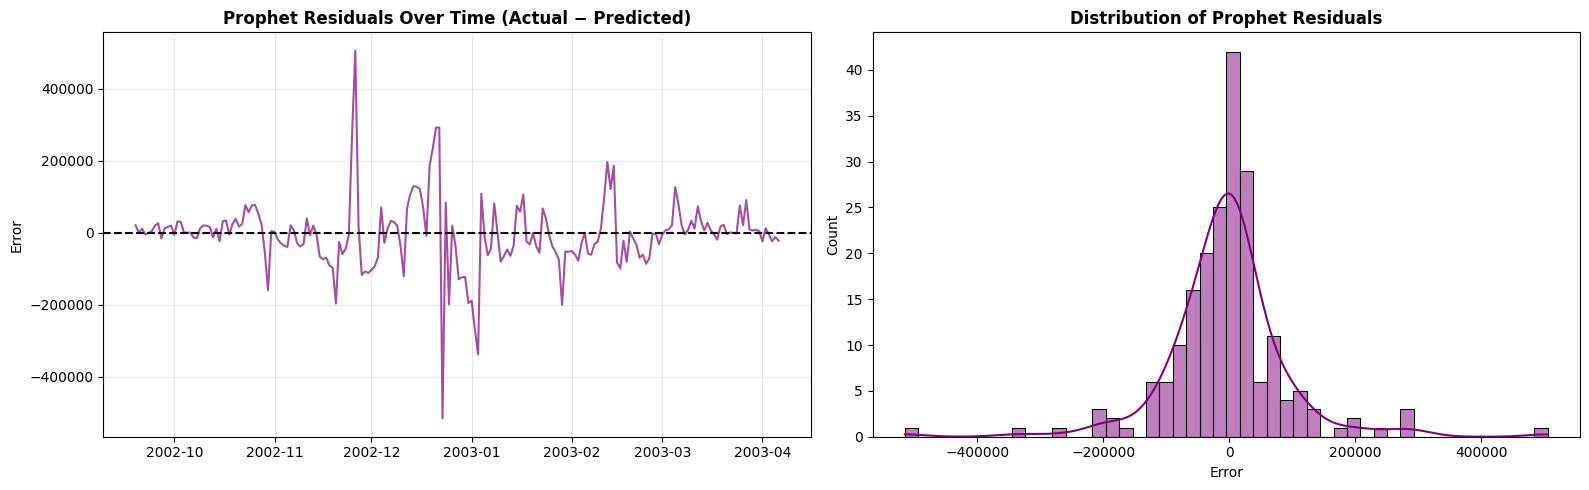

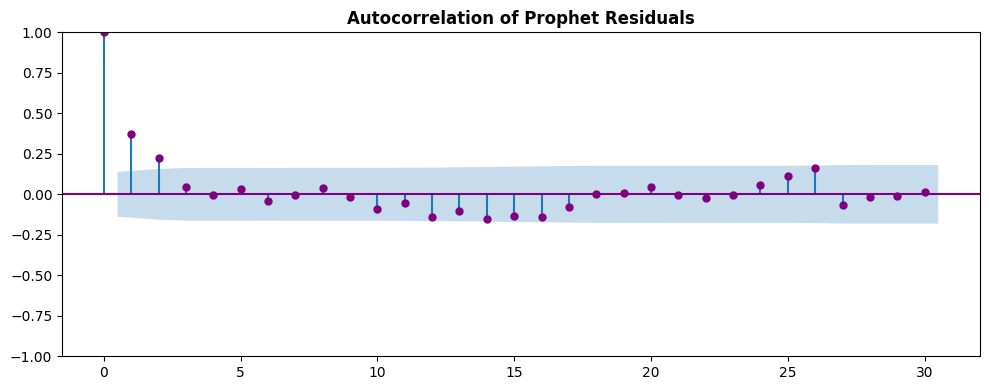

In [21]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# ── Prophet residuals ────────────────────────────────────────────────────
residuals_series = y_test - pred_prophet

# ── 1. Residuals over time + Distribution ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(residuals_series, color='purple', alpha=0.7)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('Prophet Residuals Over Time (Actual − Predicted)', fontweight='bold')
ax1.set_ylabel('Error')
ax1.grid(True, alpha=0.3)

sns.histplot(residuals_series, kde=True, ax=ax2, color='purple')
ax2.set_title('Distribution of Prophet Residuals', fontweight='bold')
ax2.set_xlabel('Error')

plt.tight_layout()
plt.show()

# ── 2. ACF of residuals ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals_series, lags=30, ax=ax, color='purple')
ax.set_title('Autocorrelation of Prophet Residuals', fontweight='bold')
plt.tight_layout()
plt.show()

To conclude the validation of the best model, we analyse the residuals ($e_t = y_t - \hat{y}_t$) to verify whether the model has extracted all predictable signal or whether exploitable structure remains.

**1. Residuals Over Time**
The residuals fluctuate around zero throughout most of the test period, indicating no systematic bias or trend drift. However, the variance is clearly non-constant: errors expand sharply during the December–January holiday window (reaching ±400,000) and are much smaller in the surrounding months. This **heteroscedasticity** is expected given the extreme event-driven spikes in this series and confirms that even multiplicative seasonality cannot fully absorb the magnitude of the most extreme holiday shocks.

**2. Distribution of Residuals**
The histogram reveals a distribution centered near zero, which confirms the model is not systematically over- or under-predicting. However, the distribution is **left-skewed** with a heavy negative tail, meaning the model's largest errors tend to be under-predictions, consistent with the visual observation that Prophet underestimates the sharpest sales peaks.

**3. Autocorrelation Function (ACF)**
The ACF plot shows significant spikes at lags 1 and 2, which fall outside the 95% confidence band. This indicates that **some short-term serial correlation remains** in the residuals, the model has not fully captured the day-to-day momentum in the series. All lags beyond 2 fall within the significance threshold, confirming that the weekly and longer-term seasonal structure has been successfully extracted. The residuals are not pure white noise, suggesting there is still marginal room for improvement, potentially through a hybrid approach that adds a short-lag correction on top of Prophet.


## 5. Conclusions

This assessment extended the analysis of daily net retail sales from Assessment 1, transitioning from purely statistical models to a comprehensive suite of machine learning approaches. The following conclusions can be drawn:

### 5.1 Overall Model Performance

Prophet emerged as the clear best performer across all metrics (MAE: 59,356 | RMSE: 96,532 | MAPE: 22.2%), representing a reduction of over **26 percentage points** in MAPE compared to the SARIMAX baseline from Assessment 1 (49.13%). This improvement validates the core hypothesis of this assessment: that the non-linear, event-driven nature of retail sales requires models capable of explicitly decomposing trend, seasonality, and holiday effects.

| Model | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| **Prophet** | **59,356** | **96,532** | **22.2** |
| XGBoost | 74,554 | 110,111 | 26.7 |
| Weighted Ensemble | 88,428 | 119,689 | 34.8 |
| Ridge Regression | 99,420 | 142,813 | 32.0 |
| Hybrid (SARIMAX + XGBoost) | 100,835 | 130,738 | 39.6 |
| MLP | 104,227 | 176,507 | 26.4 |
| *SARIMAX (Assessment 1)* | *121,217* | *149,494* | *49.13* |
| Random Forest | 157,843 | 203,076 | 67.8 |

### 5.2 Key Findings by Model Family

**Linear models (Ridge, Lasso)** confirmed the expected ceiling of purely linear approaches. Despite the addition of exogenous calendar features, Ridge (MAE: 99,420) tracks the weekly rhythm but systematically underestimates the holiday spikes. Both linear models converged to nearly identical performance, confirming that the bottleneck is the linearity assumption itself, not the regularisation strategy.

**Tree-based models** showed mixed results. XGBoost (MAE: 74,554) was the best ML model overall, benefiting from deeper trees (`max_depth=6`) and subsampling to balance bias and variance. Random Forest, despite achieving the best CV MAE (40,601), severely overfit on the test set (MAE: 157,843) due to unconstrained tree growth (`max_depth=None`), highlighting the risk of optimising CV metrics without constraining model complexity. The weighted ensemble (MAE: 88,428) was partially contaminated by Random Forest's poor generalisation.

**MLP** achieved a competitive MAPE (26.4%) but the highest RMSE (176,507), indicating large absolute errors on extreme spikes. With only ~787 training observations, the network struggled to generalise the holiday shock patterns beyond the training distribution.

**Prophet** succeeded where all other models failed by explicitly modelling all structural drivers of this series: a steady upward trend, multiplicative weekly and yearly seasonality, and US national holiday effects. The grid search confirmed that multiplicative mode outperforms additive, consistent with the observation that seasonal amplitudes scale with the overall sales level.

**The hybrid SARIMAX + XGBoost** achieved a 17% improvement over SARIMAX alone (MAE: 100,835), but remained well below Prophet. The XGBoost correction added value during the holiday build-up but introduced systematic errors in the post-holiday window, where residual patterns from training did not generalise to the test set.

### 5.3 Limitations and Future Work

Despite Prophet's strong performance, the residual analysis revealed two remaining weaknesses: **heteroscedasticity** concentrated around the December–January holiday window, and **short-term serial correlation** at lags 1–2, indicating that day-to-day momentum within extreme events is not fully captured.

Future improvements could include:

- A **Prophet + short-lag autoregressive correction**, where a lightweight AR(2) model is fitted on Prophet's residuals to absorb the remaining day-to-day momentum.
- **External regressors** in Prophet (e.g. promotional calendars, economic indicators) to better anticipate the magnitude of holiday spikes.
- A **larger training window**, which would particularly benefit the MLP and potentially unlock more complex gradient boosting configurations.
- A **proper recursive hybrid pipeline** that correctly propagates SARIMAX residuals into the ML correction stage, avoiding the feature misalignment identified in Section 3.5.1.